In [36]:
import uproot
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import norm


Definimos Variables

In [37]:
#Carpeta donde están guardados todos los outputs de root (directorio de trabajo de python + rootArchives)
base_folder = './rootArchives/posterViena/'

#Carpeta donde están guardados todos los espectros de referencia en el secundario
spectra_folder = './Espectros/'



fit_parameters_wo_uncertainties_true = { 'f_CF3':0.09625, 'f_ar_exc*P2A1':0.2905, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}



fit_parameters_wo_uncertainties = { 'f_CF3':1, 'f_ar_exc*P2A1':1, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}


#Parámetros de referencia de los espectros de mezclas de CF4
pars_ref = {"mu_230": 236.13/ 236.13 * 230, "sigma_230": 11.19 * 1.1, "A_230": 4.77, "mu_260": 259.30, "sigma_260": 13.63 * 1.5, 
                    "mu_290": 289.00 / 289 * 295, "sigma_290": 20.90, "A_290": 5.64, "mu_400": 373.6, "sigma_400": 50.94, "A_400": 1.16,
                    "mu_620": 630.77, "sigma_620": 39.85 * 1.2}



#resultados de los fits al primario en el IR
path_results_ir = 'IR_fit_results_2.csv'
df_results_ir = pd.read_csv(path_results_ir)


Datos Ar_CF4

In [38]:
ar_cf4_experimental_concs = np.array([5, 10, 67, 100])
ar_cf4_experimental_phe_e_visir = np.array([0.575117370892018, 0.548826291079812, 0.300156494522691, 0.0926277372262773])
ar_cf4_experimental_phe_e_vis = np.array([0.38287151, 0.38966203, 0.2802068, 0.09335376])
ar_cf4_experimental_errors_vis = np.array([ 0.005477291487030911, 0.010954582974061933, 0.005478365465753865, 0.007668231611893575])
ar_cf4_systematical_errors_vis = 0.2 * ar_cf4_experimental_phe_e_visir
ar_cf4_total_errors_vis = np.sqrt(ar_cf4_experimental_errors_vis**2 + ar_cf4_systematical_errors_vis**2)
ar_cf4_experimental_concs_uv = np.array([5, 67, 100])
ar_cf4_experimental_phe_e_uv = np.array([0.06737771706391489,0.08455236611728804, 0.044033601820777875, 0.03942121448304051])
# ar_cf4_experimental_errors_uv = np.array([0.0006416905744254584, 0.0016876667997495743, 0.000803687969275206, 0.0032635041309454767])
# ar_cf4_systematical_errors_uv = 0.2 * ar_cf4_experimental_phe_e_uv
# ar_cf4_total_errors_uv = np.sqrt(ar_cf4_experimental_errors_uv**2 + ar_cf4_systematical_errors_uv**2)
ar_cf4_total_errors_uv = np.array([0.013490812870036886, 0.016994479521607656, 0.00884331537513073, 0.00859011077564899])
# [{696: 0.001903750857308241, 727: 0.0, 750: 0.032740923494724225, 763: 0.03019608864843109, 772: 0.011068235090279443, 794: 0.0035142251232868483},
#   {696: 0.001353869286904855, 727: 0.0014046229827858194, 750: 0.018281920924238942, 763: 0.0116498167952746, 772: 0.004904421042062652, 794: 0.0}, 
#   {696: 0.0017491907378617108, 727: 0.0009719966454432347, 750: 0.004780564636384211, 763: 0.0013332818786436103, 772: 0.0006417759550378386, 794:0.00014184138002102336}]
# [{696: 0.00038118160849460943, 727: 0.0, 750: 0.006555604602045478, 763: 0.00604606091026497, 772: 0.0022161553538967557, 794: 0.00070364143499359},
#  {696: 0.00027211898291908023, 727: 0.0002823201480065063, 750: 0.0036745480349024023, 763: 0.0023415379373670124, 772: 0.0009857569550337352, 794: 0.0}, 
#  {696: 0.0003512918477377346, 727: 0.00019520712646240219, 750: 0.000960085911727398, 763: 0.000267764426466441, 772: 0.00012888855183082695, 794: 2.848615613764747e-05}]


ar_cf4_experimental_phe_e_ir =  [{696: 0.0007423954814679462, 727: 0.0, 750: 0.030352019422880832, 763: 0.028478502055388058, 772: 0.009542209996882418, 794: 0.0032255060792284705}, 
 {696: 0.00016606742822049213, 727: 0.00023289581724378054, 750: 0.01646440994283698, 763: 0.010520420255841482, 772: 0.00406238907466698, 794: 0.0}, 
 {696: 5.7976067957635574e-05, 727: 0.00013834145604106908, 750: 0.004112455696967686, 763: 0.0009514346999852515, 772: 0.0003514776387269656, 794: 0.00010916911326505648}]
ar_cf4_total_errors_ir = [{696: 0.00014864734147261504, 727: 0.0, 750: 0.006077282402925308, 763: 0.0057021543440504, 772: 0.0019106045001854228, 794: 0.0006458321953051536}, 
                          {696: 3.337848055232784e-05, 727: 4.681055514551999e-05, 750: 0.003309240065745319, 763: 0.0021145365269683238, 772: 0.0008165139677163302, 794: 0.0}, 
                          {696: 1.1643395769579259e-05, 727: 2.778326265939665e-05, 750: 0.0008259088784642111, 763: 0.00019107764895222087, 772: 7.058763031059062e-05, 794: 2.1924549841632906e-05}]

E_fields_ar_cf4 = {5:65, 10:78, 67:88, 100:95}

yields_cf4_100_25_mbar = {'vis':0.04953590534192422, 'uv': 0.1367619130620444}
yields_arcf4_8020_50_mbar = {'vis':0.1057123306627957, 'uv':0.02769685258037305,
                             'ir':{696: 0.002246119186430594, 727: 0.0005887938444242574, 750: 0.057088337541668865, 763: 0.02364076551779444, 772: 0.00668799699933377, 794: 0.004140203178868282} }
                            #  'ir': {696: 0.0006599091472513375, 727: 0.00036670070538431836, 750: 0.0018035416403088772, 763: 0.0005030011241981122, 772: 0.0002421198638023633, 794: 5.3511845282836466e-05}}
errors_arcf4_8020_50mbar = {'ir': {696: 0.00048240607489727035, 727: 0.0001264571039365711, 750:0.012261041623375114, 763: 0.005077401488711407, 772: 0.0014364021289985191, 794: 0.0008892044450984726}}
#{'ir': {696: 0.00014173076096652608, 727: 7.875746265612322e-05, 750: 0.0003873523047536083, 763: 0.00010803113185588904, 772: 5.200084388093932e-05, 794: 1.1492907143732655e-05}}




yields_arcf4_8020_1_bar = {'vis':0.3542058185498147, 'uv':0.04599727051007351,
                        'ir': {696: 0.0012121110778869518, 727: 0.0009963113528044523, 750: 0.010641617291858389, 763: 0.005277639438703508, 772: 0.0018895075477094276, 794:0.0}}
errors_arcf4_8020_1_bar = {'ir': {696: 0.00026032890460820274, 727: 0.0002139809196170797, 750: 0.0022855335813600896, 763: 0.0011334952044080517, 772: 0.0004058154727878853, 794: 0.0}}


Datos He_CF4

In [39]:
he_cf4_experimental_concs = np.array([20, 40, 100])
he_cf4_experimental_phe_e_visir = np.array([0.0668231611893583, 0.0701095461658841, 0.0926277372262773])
he_cf4_experimental_phe_e_vis = np.array([0.05981728, 0.0633149, 0.09335376])
he_cf4_experimental_errors_vis = np.array([0.010954582974061822, 0.019718249353311457, 0.007668231611893575])
he_cf4_systematical_errors_vis = 0.2 * he_cf4_experimental_phe_e_vis
he_cf4_total_errors_vis = np.sqrt(he_cf4_systematical_errors_vis**2 + he_cf4_experimental_errors_vis**2)
he_cf4_experimental_phe_e_uv = np.array([0.0586689111317149, 0.12606696047521188, 0.03942121448304051])
he_cf4_experimental_errors_uv = np.array([0.009617824771399473, 0.03545622383551968, 0.0032635041309454767])
he_cf4_systematical_errors_uv = 0.2 * he_cf4_experimental_phe_e_uv
he_cf4_total_errors_uv = np.sqrt(he_cf4_systematical_errors_uv**2 + he_cf4_experimental_errors_uv**2)
he_cf4_total_errors_uv = np.array([0.014241770732051665, 0.04213797898747448, 0.00859011077564899])

E_fields_he_cf4 = {20: 60, 40:75, 100:95}


yields_hecf4_8020_300_mbar = {'vis':0.03459508998978698, 'uv':0.0709633243946791}


Definimos funciones

In [40]:
def open_root(P, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b='cf4', **kwargs):

    P_str = f'{P:.3f}'.rstrip('0').rstrip('.')

    if conc_b == 100:
        root_path = base_folder + f'ar100.0{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    else:
        root_path = base_folder + f'{gas_a}{conc_b:.1f}{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    root_file = uproot.open(root_path)

    hLevels = root_file['hLevels'].values()

    return root_file, hLevels


In [41]:
def open_spectrum(P, gas_a, conc_b, origin, gas_b='CF4'):
    spectrum_path = spectra_folder + f'{gas_a}{gas_b}_{100 - conc_b}{conc_b:02d}_{P}_bar_{origin}.csv'

    spectrum_df = pd.read_csv(spectrum_path, delimiter=';', decimal=',', header=None)

    return spectrum_df

In [54]:
root_file, hLevels = open_root(1, 'ar', 95, 5, 52, 0.05, 10000)

n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
print(n_e)

118759


In [42]:
ratio_cf3_exc_uv_vis = 0.17394463
#ratio_cf3_exc_uv_vis = 0.190905093 /3


def ph_e(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, quench_ion, df_results_ir, P_ar_ir=1e-6, n_start_ar=0, n_start_he=0, n_start_cf4=0, gas_b='cf4', tope=False, include_cf3=True, **kwargs):

    positions = [696, 727, 750, 763, 772, 794]
    ns_start_ir = {696 : 20, 727: 20, 750: 21, 763:16, 772:20, 794:18}
    lifetimes = {696: 28.3, 727: 28.3, 750: 21.7, 763: 29.4, 772: 28.3, 794: 29.3}

    root_file, hLevels = open_root(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b, **kwargs)


    n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
    n_i = sum(root_file['dataPerPrimaryElectron;1']['nIons'].array())

    n_exc_ar_vis, n_exc_he_vis, n_ion_ar_uv, n_ion_he_uv = 0, 0, 0, 0
    n_exc_vis, n_ion_uv, n_exc_dir_vis, n_ion_dir_uv = 0, 0, 0, 0
    n_exc_ar_ir = {696: 0, 727: 0, 750: 0, 763: 0, 772: 0, 794: 0}

    if conc_b == 100:
            index_start_direct = 23 + n_start_cf4

            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 44])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_dir_uv = hLevels[1] + hLevels[6] #Canal directo es el que produce CF3+ de algún modo

            

    else:
        
        if gas_a == 'ar':
            index_start_ar = 8 + n_start_ar #seleccionamos desde que estado empezamos a contar
            n_exc_ar_vis = sum(hLevels[index_start_ar:52])
            n_exc_vis = n_exc_ar_vis
            index_start_direct = 75 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 96])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_ar_uv = hLevels[2] + hLevels[3]#0 #non encontro ionizacións dobles e triples, a sección eficaz debe ser baixa
            n_ion_uv = n_ion_ar_uv
            n_ion_dir_uv = hLevels[53] + hLevels[58] + hLevels[60]#Canal directo es el que produce CF3+ de algún modo

            for pos in positions:
                n_start_ir = ns_start_ir[pos]
                n_exc_ar_ir[pos] = sum(hLevels[n_start_ir:52])

        elif gas_a == 'he':
            index_start_he = 4 + n_start_he
            n_exc_he_vis = 0#sum(hLevels[index_start_he:53])
            n_exc_vis = n_exc_he_vis
            index_start_direct = 76 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 97])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_he_uv = hLevels[1] #A energía de ionización do helio e 24.59 eV, suficiente para ionizar CF4
            n_ion_uv = n_ion_he_uv
            n_ion_dir_uv = hLevels[54] + hLevels[59] + hLevels[61]#Canal directo es el que produce CF3+ de algún modo

        else:
            print(f'El gas A introducido: {gas_a} no es válido')

    conc_b *= 1e-2
    conc_a *= 1e-2

    ph_e_vis = n_exc_dir_vis / n_e * kwargs['f_CF3'] + n_exc_vis / n_e * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )

    ph_i_vis = n_exc_dir_vis / n_i * kwargs['f_CF3'] + n_exc_vis / n_i * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )
    
    if include_cf3:
        cf3_e_uv = ratio_cf3_exc_uv_vis * ph_e_vis * 0.35
        cf3_i_uv = ratio_cf3_exc_uv_vis * ph_i_vis * 0.35
    else:
        cf3_e_uv = 0
        cf3_i_uv = 0

    
    ph_e_uv = (n_ion_dir_uv / n_e * kwargs['f_CF4']+ n_ion_uv / n_e * ( Pressure * conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + Pressure * conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
              Pressure * conc_b / ( Pressure * conc_b + kwargs['tau_1_K_cool']
             )  * 1 / (1 + kwargs['K_scint_tau_2'] * Pressure * conc_b)) / quench_ion + cf3_e_uv #Metemos este quench_ion para introducir la probablididad de que el CF4+ llegueal estado que emite
            

    
    ph_i_uv = (n_ion_dir_uv / n_i * kwargs['f_CF4']+ n_ion_uv / n_i * ( Pressure * conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + Pressure * conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
             Pressure * conc_b / ( Pressure * conc_b + kwargs['tau_1_K_cool']
            )  * 1 / (1 + kwargs['K_scint_tau_2'] * Pressure * conc_b)) / quench_ion + cf3_i_uv#Metemos este 5 para introducir la probablididad de que el CF4+ llegueal estado que emite
            
    K_cf4_p_ar = {pos : df_results_ir[df_results_ir['line_nm'] == pos].iloc[0]['K_cf4'] for pos in positions}
    K_ar_p_ar = {pos : df_results_ir[df_results_ir['line_nm'] == pos].iloc[0]['K_ar'] for pos in positions}

    p_change_ir = 2.5 #measures the change on teh probability of scintillation between primary and secondary sinctillation
    ph_e_ir = {pos : p_change_ir * lifetimes[pos] / n_e * n_exc_ar_ir[pos]  / (1 + conc_b * Pressure * lifetimes[pos] * K_cf4_p_ar[pos] + 
                                             conc_a * Pressure * lifetimes[pos] * K_ar_p_ar[pos] )
                                             for pos in positions}
    
    print(n_exc_ar_ir)
    print(n_e)

    ph_e_ir_lowP = {pos : p_change_ir * lifetimes[pos] / n_e * n_exc_ar_ir[pos]  / (1  + conc_b * Pressure * lifetimes[pos] * K_cf4_p_ar[pos] + 
                                             conc_a * Pressure * lifetimes[pos] * K_ar_p_ar[pos])
                                             for pos in positions}
    # print([lifetimes[pos] for pos in positions])
    # print(Pressure)
    # print(conc_b, conc_a)
    # print(n_exc_ar_ir)
    
    # print(n_e)
    
    # ph_e_ir_lowP = {pos : lifetimes[pos] / n_e * n_exc_ar_ir[pos]  / (1 / P_ar_ir )
    #                                          for pos in positions}
    

    dic_values = {
        'n_exc_ar_vis':n_exc_ar_vis, 'n_exc_he_vis':n_exc_he_vis, 'n_ion_ar_uv':n_ion_ar_uv, 
        'n_ion_he_uv':n_ion_he_uv, 'n_exc_dir_vis':n_exc_dir_vis, 'n_ion_dir_uv':n_ion_dir_uv,
    }

    return ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir, ph_e_ir_lowP, dic_values

In [43]:
def array_ph_e(P_start, P_stop, P_step, E_field, dic_Ps, Pressure, conc_a, conc_b, gas_a, gap, npe, tope=False, **kwargs):
    ph_e_vis_array = []
    ph_i_vis_array = []
    ph_e_uv_array = []
    ph_i_uv_array = []
    #E_field = dic_E_fields[conc_b]

    for P in np.arange(P_start, P_stop, P_step):
        P = round(P, 2)

        n_start_transfer, n_start_dir = dic_Ps[P]

        if gas_a == 'ar':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'ar', conc_a, conc_b, E_field, gap, npe, tope=tope, n_start_ar=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        elif gas_a == 'he':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'he', conc_a, conc_b, E_field, gap, npe, tope=tope ,n_start_he=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        ph_e_vis_array.append(P * ph_e_vis)
        ph_i_vis_array.append(P * ph_i_vis)
        ph_e_uv_array.append(ph_e_uv)
        ph_i_uv_array.append(ph_i_uv)

    return ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array

In [44]:
def array_ph_e_uv(quench_start, quench_stop, quench_step, E_field, dic_P, Pressure, conc_a, conc_b, gas_a, gap, npe, tope=False, **kwargs):
    ph_e_vis_array = []
    ph_i_vis_array = []
    ph_e_uv_array = []
    ph_i_uv_array = []
    #E_field = dic_E_fields[conc_b]
    n_start_transfer, n_start_dir = dic_P

    for q in np.arange(quench_start, quench_stop, quench_step):
        

        if gas_a == 'ar':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'ar', conc_a, conc_b, E_field, gap, npe, tope=tope, quench_ion=q, n_start_ar=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        elif gas_a == 'he':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'he', conc_a, conc_b, E_field, gap, npe, tope=tope , quench_ion=q, n_start_he=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        ph_e_vis_array.append(0.35 * ph_e_vis)
        ph_i_vis_array.append(0.35 * ph_i_vis)
        ph_e_uv_array.append(ph_e_uv)
        ph_i_uv_array.append(ph_i_uv)

    return ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array

In [45]:
def gaussian(x, mean,A, sigma):
    return A * np.exp(-(x- mean) ** 2 / 2 / sigma **2)

In [46]:
def spectrum_absolute(wavelength, intensity, ph_e_exp_uv, ph_e_exp_vis):
    mask = wavelength < 720

    total_integral = np.trapezoid(intensity[mask], wavelength[mask])

    
    intensity_corrected = intensity / total_integral * (ph_e_exp_uv + ph_e_exp_vis)

    return intensity_corrected

In [47]:
def spectrum_generator(P, gas_a, conc_b, origin, reference_parameters, ph_e_uv, ph_e_vis, phe_e_exp_uv, ph_e_exp_vis, gas_b='CF4', comparison=True):

    ratio_230_290 = reference_parameters['A_230'] / reference_parameters['A_290']
    #print(ratio_230_290)
    ratio_400_290 = reference_parameters['A_400'] / reference_parameters['A_290']


    A_ion_UV = (ph_e_uv - ph_e_vis * ratio_cf3_exc_uv_vis)  / np.sqrt(2 * np.pi) / (ratio_230_290 * reference_parameters['sigma_230'] + reference_parameters['sigma_290'] +
                                             ratio_400_290 * reference_parameters['sigma_400'])

    A_exc_vis = ph_e_vis / np.sqrt(2 * np.pi) / reference_parameters['sigma_620']
    A_exc_UV = ratio_cf3_exc_uv_vis * ph_e_vis / np.sqrt(2 * np.pi) / reference_parameters['sigma_260']

    x_plot = np.linspace(200, 800, 2000)

    gaussian_230 = ratio_230_290 * A_ion_UV * reference_parameters['sigma_230'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_230'], reference_parameters['sigma_230'])
    gaussian_260 =  A_exc_UV * reference_parameters['sigma_260'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_260'], reference_parameters['sigma_260'])
    gaussian_290 =  A_ion_UV * reference_parameters['sigma_290'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_290'], reference_parameters['sigma_290'])
    gaussian_400 = ratio_400_290 * A_ion_UV * reference_parameters['sigma_400'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_400'], reference_parameters['sigma_400'])
    gaussian_620 =  A_exc_vis * reference_parameters['sigma_620'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_620'], reference_parameters['sigma_620'])

    # gaussian_230 = gaussian(x_plot, reference_parameters['mu_230'], ratio_230_290 * A_ion_UV, reference_parameters['sigma_230'])
    # gaussian_260 =    gaussian(x_plot, reference_parameters['mu_260'], A_exc_UV, reference_parameters['sigma_260'])
    # gaussian_290 =   gaussian(x_plot, reference_parameters['mu_290'], A_ion_UV, reference_parameters['sigma_290'])
    # gaussian_400 =  gaussian(x_plot, reference_parameters['mu_400'], ratio_400_290 * A_ion_UV , reference_parameters['sigma_400'])
    # gaussian_620 =   gaussian(x_plot, reference_parameters['mu_620'], A_exc_vis, reference_parameters['sigma_620'])
    
    y_plot =  gaussian_230 + gaussian_260 + gaussian_290 + gaussian_400 + gaussian_620

    fig, ax = plt.subplots(dpi = 150)

    ax.plot(x_plot, y_plot, label='Predicted curve')

    # idx_630 = np.argmin(np.abs(x_plot - 630))
    # norm_factor = y_plot[idx_630]

    if comparison:
        spectrum_df = open_spectrum(P, gas_a, conc_b, origin, gas_b)


        wavelength = spectrum_df[0]
        intensity = spectrum_df[1]

        mask = (wavelength >= 200) & (wavelength <= 400)
        

        # idx_630_exp = np.argmin(np.abs(wavelength - 630))
        # norm_exp = intensity[idx_630_exp]

        intensity_plot = spectrum_absolute(wavelength, intensity, phe_e_exp_uv, ph_e_exp_vis)
        print(np.trapezoid(intensity_plot[mask], wavelength[mask]))

        ax.plot(wavelength, intensity_plot, label='Experimental spectrum')

    # print(max(y_plot))
    ax.legend()
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('ph/e$^-$')
    #ax.set_ylim(0, 0.0001)

    lines = [230, 260, 290, 320, 630]

    for line in lines:
        ax.axvline(line, linestyle='--', linewidth=1, alpha=0.7)

    ax.set_title(f'{gas_a}{gas_b} {100 - conc_b}/{conc_b}  {P}bar Spectrum')

In [48]:
def scan_P_ar_ir(P_start, P_stop, P_step, Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, quench_ion, df_results_ir, n_start_ar=0, n_start_he=0, n_start_cf4=0, gas_b='cf4', tope=False, include_cf3=True, **kwargs):
    ph_e_ir_array = []
    P_array = np.arange(P_start, P_stop, P_step)

    for P_ar in P_array:
        ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir, ph_e_ir_lowP, dic_values = ph_e(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, quench_ion,df_results_ir, P_ar_ir=P_ar, **kwargs)
        ph_e_ir_array.append(ph_e_ir_lowP)
    
    return ph_e_ir_array

In [49]:
dic_Ps_to_states_5 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(5, 19), 0.45:(11, 20), 0.5:(15, 20), 0.55:(16, 21), 0.6:(18, 21), 
                    0.65:(21, 22), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(26, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_10 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(6, 19), 0.45:(12, 20), 0.5:(15, 20), 0.55:(17, 21), 0.6:(19, 21), 
                    0.65:(21, 21), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(27, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_20 = {0.1: (-8, 0), 0.15: (-8, 11), 0.2: (0, 12), 0.25: (2, 13), 0.3: (3, 17), 0.35: (3, 19), 
                       0.4: (7, 19), 0.45: (13, 20), 0.5: (15, 20), 0.55: (17, 21), 0.6: (19, 21), 0.65: (21, 21), 
                       0.7: (23, 22), 0.75: (23, 22), 0.8: (24, 22), 0.85: (26, 23), 0.9: (29, 23), 0.95: (29, 23), 
                       1.0: (29, 23)}

dic_Ps_to_states_67 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(2, 13), 0.3:(3, 15), 0.35:(3, 18),
                    0.4:(8, 19), 0.45:(13, 19), 0.5:(15, 20), 0.55:(17, 20), 0.6:(18, 21), 
                    0.65:(20, 21), 0.7:(23, 21), 0.75:(23, 22), 0.8:(23, 22), 0.85:(24, 22), 
                    0.9:(26, 22), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_100 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 12), 0.3:(3, 14), 0.35:(3, 16),
                    0.4:(6, 18), 0.45:(12, 19), 0.5:(15, 19), 0.55:(17, 20), 0.6:(19, 20), 
                    0.65:(21, 20), 0.7:(23, 21), 0.75:(23, 21), 0.8:(24, 21), 0.85:(27, 22), 
                    0.9:(29, 22), 0.95:(29, 22), 1:(29, 22)}

dic_Ps_to_states_he_20 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 15), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 19), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 20), 0.75: (6, 21), 0.8: (8, 21), 0.85: 
                          (9, 21), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)}

dic_Ps_to_states_he_40 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 16), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 20), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 21), 0.75: (5, 21), 0.8: (8, 21), 
                          0.85: (9, 22), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)} #Feito con Degrad de He/CF4 de 50/50


fig_ar_ir_primary, ax_ar_ir_primary = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]

for conc_b, ph_e_experimental, error in zip(ar_cf4_experimental_concs[:-1], ar_cf4_experimental_phe_e_ir, ar_cf4_total_errors_ir):

    

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, quench_ion=1, df_results_ir=df_results_ir,
                                                             include_cf3=False, **fit_parameters_wo_uncertainties)
    
    
    
    ax_ar_ir_primary.plot(conc_b / 100, ph_e_uv , 'o', color='r', label=f'Simulated IR {conc_b}% CF4')
    ax_ar_ir_primary.errorbar(conc_b / 100, ph_e_experimental, yerr=error, marker='s', color='k', label=f'Experimental IR {conc_b}% CF4', capsize=4)


ax_ar_ir_primary.set_title('ph/e IR in Ar/CF4 (Primary scintillation model)')

ax_ar_ir_primary.set_xlabel('CF4 Fraction')
ax_ar_ir_primary.set_ylabel('ph/e$^-$')
ax_ar_ir_primary.set_ylim(0)
ax_ar_ir_primary.set_xscale('log')

{696: np.float64(575694.0), 727: np.float64(575694.0), 750: np.float64(563924.0), 763: np.float64(653846.0), 772: np.float64(575694.0), 794: np.float64(613809.0)}
664128
{696: np.float64(2473111.0), 727: np.float64(2473111.0), 750: np.float64(2424647.0), 763: np.float64(2805590.0), 772: np.float64(2473111.0), 794: np.float64(2635770.0)}
3374271
{696: np.float64(1144617.0), 727: np.float64(1144617.0), 750: np.float64(1123389.0), 763: np.float64(1296321.0), 772: np.float64(1144617.0), 794: np.float64(1219122.0)}
3657243
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(121537729.0), 727: np.float64(121537729.0), 750: np.float64(118452400.0), 763: np.float64(139060137.0), 772: np.float64(121537729.0), 794: np.float64(129875942.0)}
63553209


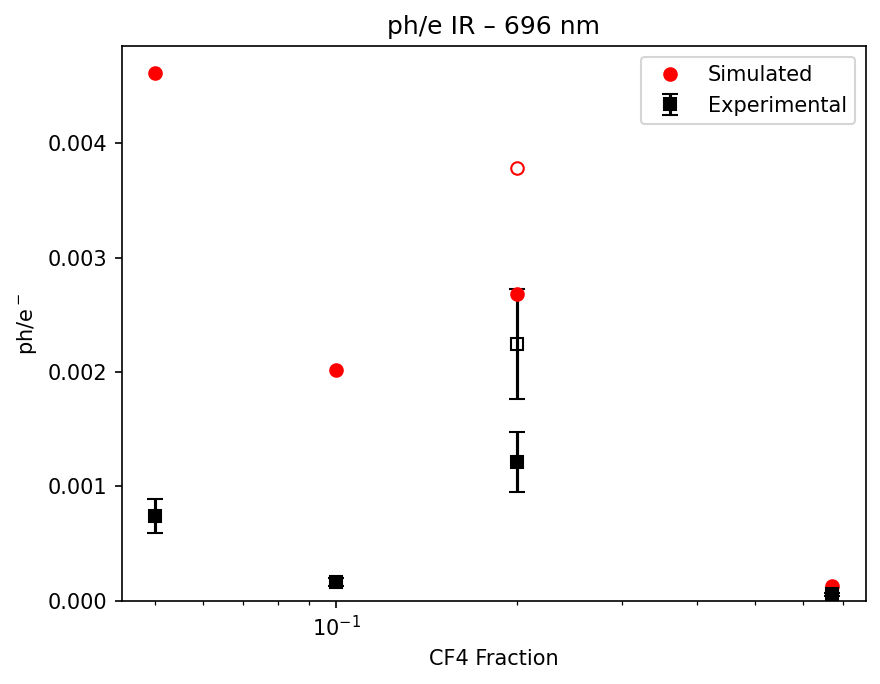

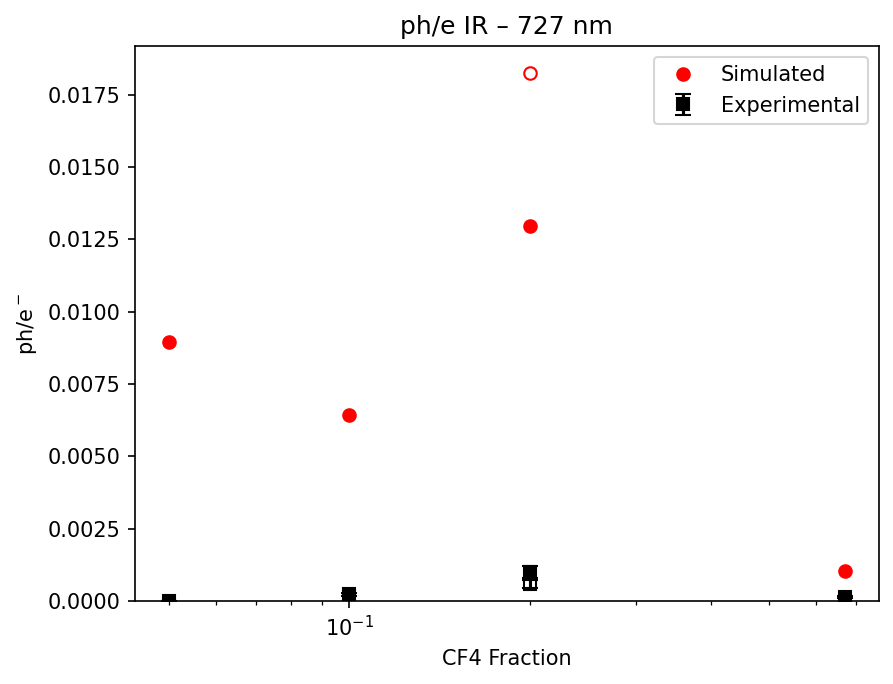

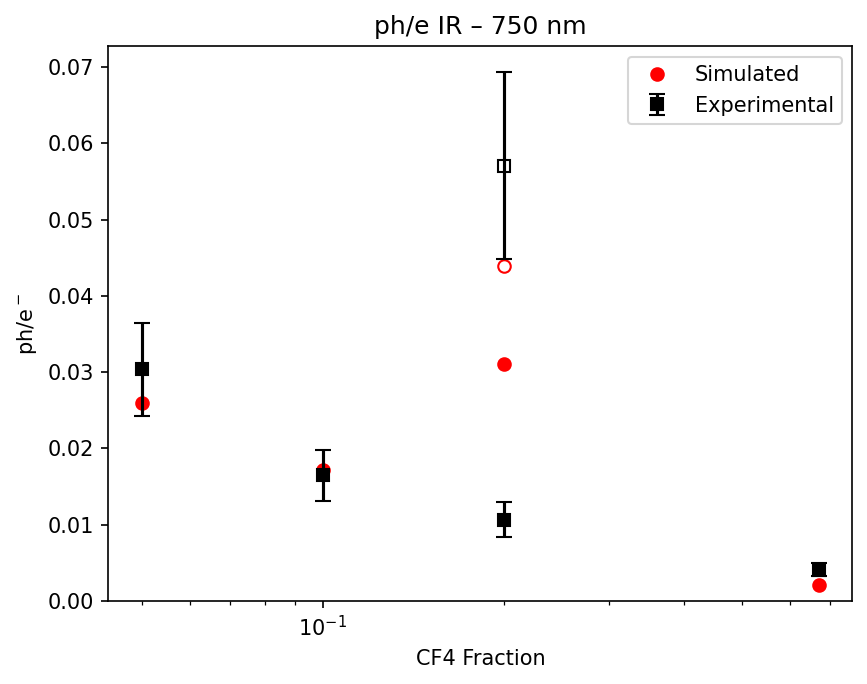

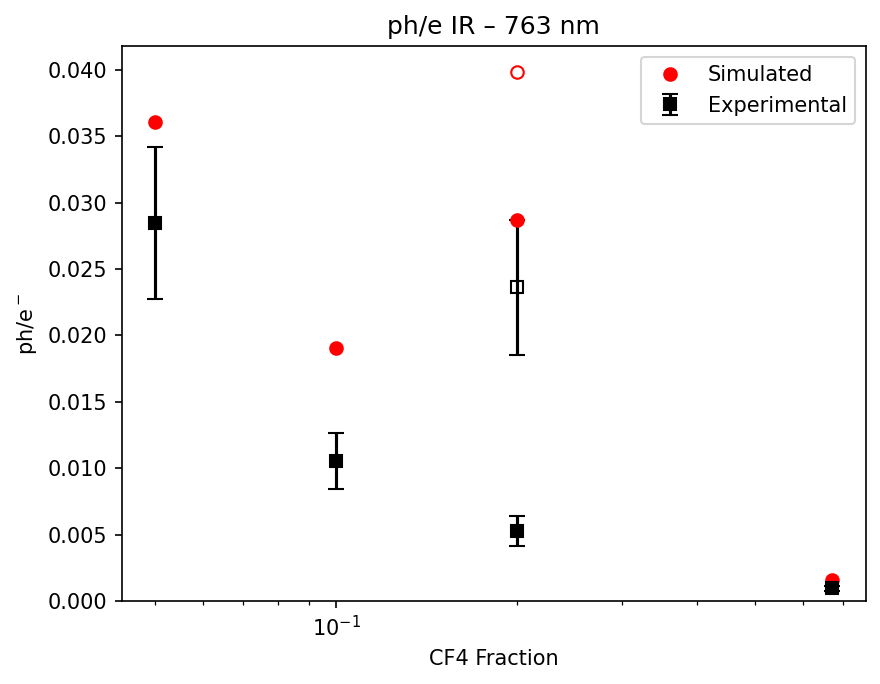

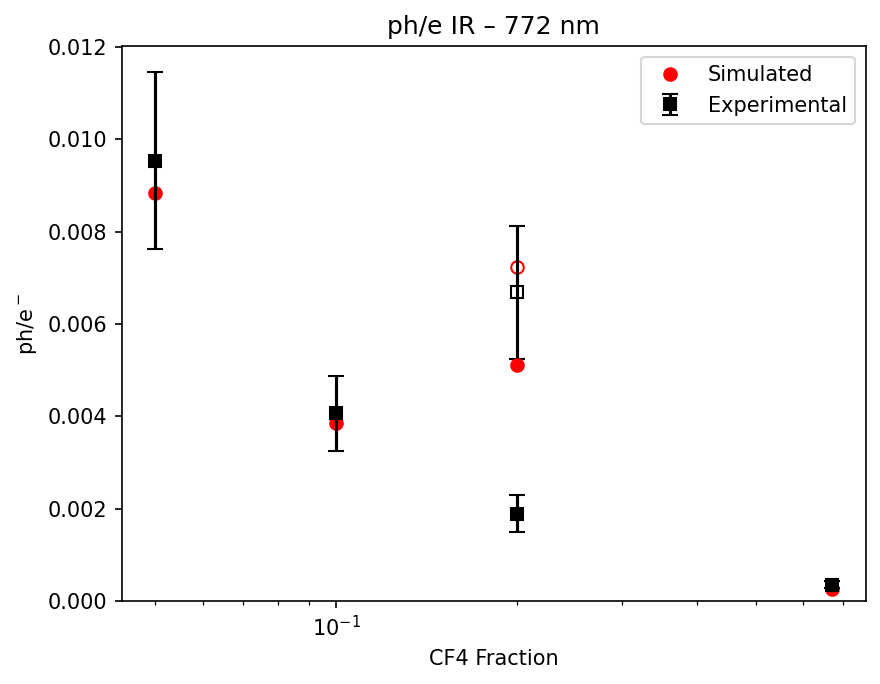

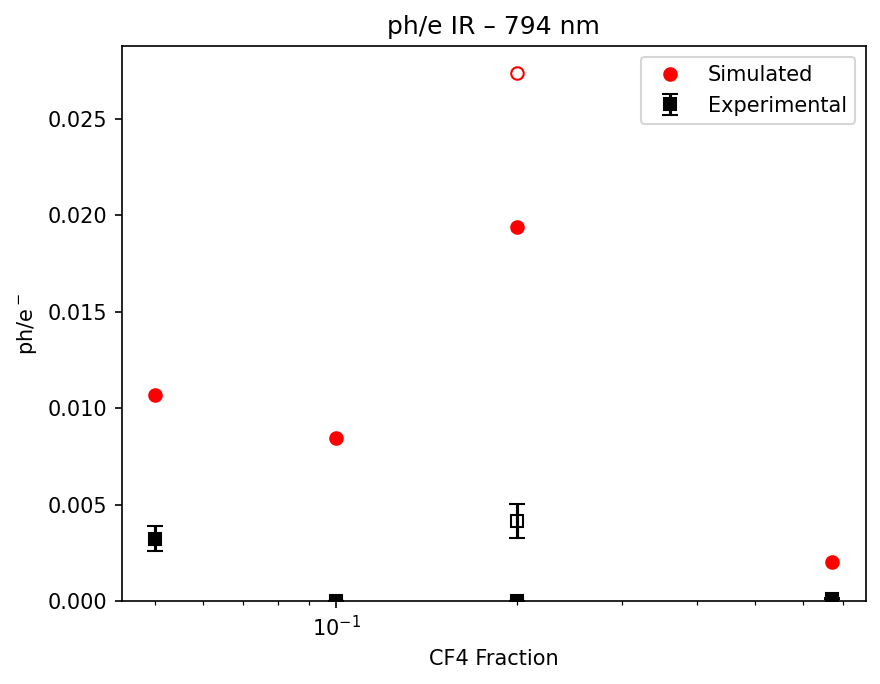

In [52]:

# Obtener lista de keys (picos)
keys = list(ar_cf4_experimental_phe_e_ir[0].keys())

# Crear estructura acumuladora
sim_data = {k: [] for k in keys}
exp_data = {k: [] for k in keys}
err_data = {k: [] for k in keys}
conc_data = []
press_data = []
markers_sim_data = []
markers_exp_data = []


# ---- Loop sobre concentraciones ----
for conc_b, ph_e_exp_dict, error_dict in zip(
        ar_cf4_experimental_concs[:-1],
        ar_cf4_experimental_phe_e_ir,
        ar_cf4_total_errors_ir):

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir_dict, ph_e_ir_lowP_dict, dic_values = ph_e(
        1, 'ar', 100-conc_b, conc_b,
        E_fields_ar_cf4[conc_b],
        0.05, 10000,
        quench_ion=1,
        df_results_ir=df_results_ir,
        include_cf3=False,
        **fit_parameters_wo_uncertainties
    )

    conc_frac = conc_b / 100
    conc_data.append(conc_frac)
    press_data.append(1)
    markers_sim_data.append('r')
    markers_exp_data.append('k')

    for k in keys:
        sim_data[k].append(ph_e_ir_dict[k])
        exp_data[k].append(ph_e_exp_dict[k])
        err_data[k].append(error_dict[k])
        


ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir_dict, ph_e_ir_lowP_dict, dic_values = ph_e(0.05, 'ar', 80, 20, 8.4, 0.57, 10000, quench_ion=1,df_results_ir=df_results_ir,include_cf3=False, **fit_parameters_wo_uncertainties)

conc_data.append(0.2)
press_data.append(0.05)
markers_sim_data.append('none')
markers_exp_data.append('none')
for k in keys:
    sim_data[k].append(ph_e_ir_dict[k])
    exp_data[k].append(yields_arcf4_8020_50_mbar['ir'][k])
    err_data[k].append(errors_arcf4_8020_50mbar['ir'][k])



ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, ph_e_ir_dict, ph_e_ir_lowP_dict, dic_values = ph_e(1, 'ar', 80, 20, 29, 0.57, 10000, quench_ion=1,df_results_ir=df_results_ir,include_cf3=False, **fit_parameters_wo_uncertainties)

conc_data.append(0.2)
press_data.append(1)
markers_sim_data.append('r')
markers_exp_data.append('k')
for k in keys:
    sim_data[k].append(ph_e_ir_dict[k])
    exp_data[k].append(yields_arcf4_8020_1_bar['ir'][k])
    err_data[k].append(errors_arcf4_8020_1_bar['ir'][k])


legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='none', label='Data GDD (25-50 mbar)'),
           

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
           color='r', markerfacecolor='none', label='Simulated (300 mbar)')
]

# ---- Crear una figura por cada key ----
for k in keys:
    fig, ax = plt.subplots(dpi=150)

    for i, (c, s, e, err, msim, mexp) in enumerate(zip(
            conc_data, sim_data[k], exp_data[k], err_data[k],
            markers_sim_data, markers_exp_data)):

        ax.plot(c, s, 'o', color='r',
                markerfacecolor=msim if msim != 'none' else 'none',
                label='Simulated' if i == 0 else '')

        ax.errorbar(c, e, yerr=err,
                    fmt='s', color='k', capsize=4,
                    markerfacecolor=mexp if mexp != 'none' else 'none',
                    label='Experimental' if i == 0 else '')

    ax.set_title(f'ph/e IR – {k} nm')
    ax.set_xlabel('CF4 Fraction')
    ax.set_ylabel('ph/e$^-$')
    ax.set_xscale('log')
    ax.set_ylim(bottom=0)
    ax.legend()



    


{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np.float64(2016.0), 763: np.float64(2314.0), 772: np.float64(2052.0), 794: np.float64(2200.0)}
15199
{696: np.float64(2052.0), 727: np.float64(2052.0), 750: np

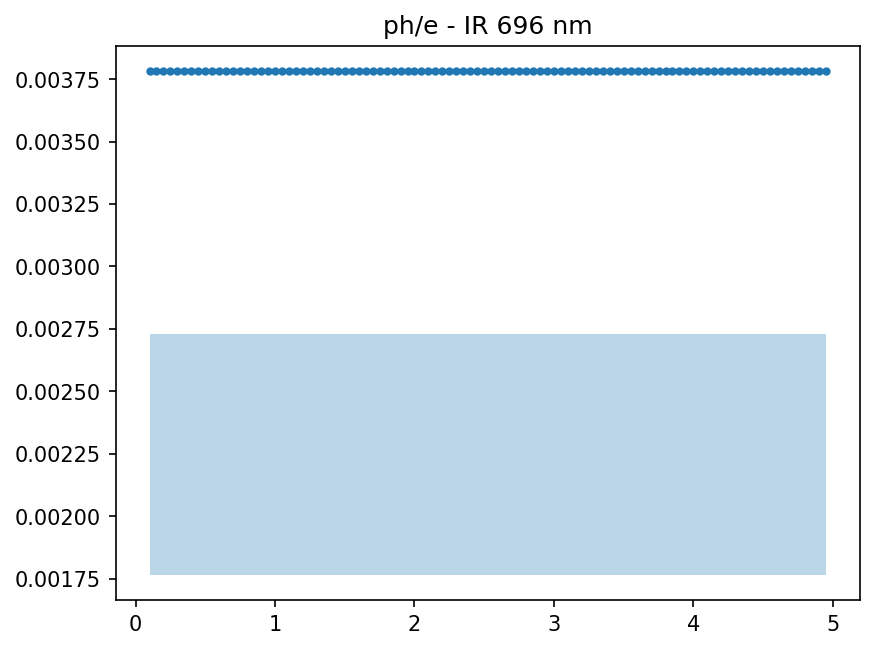

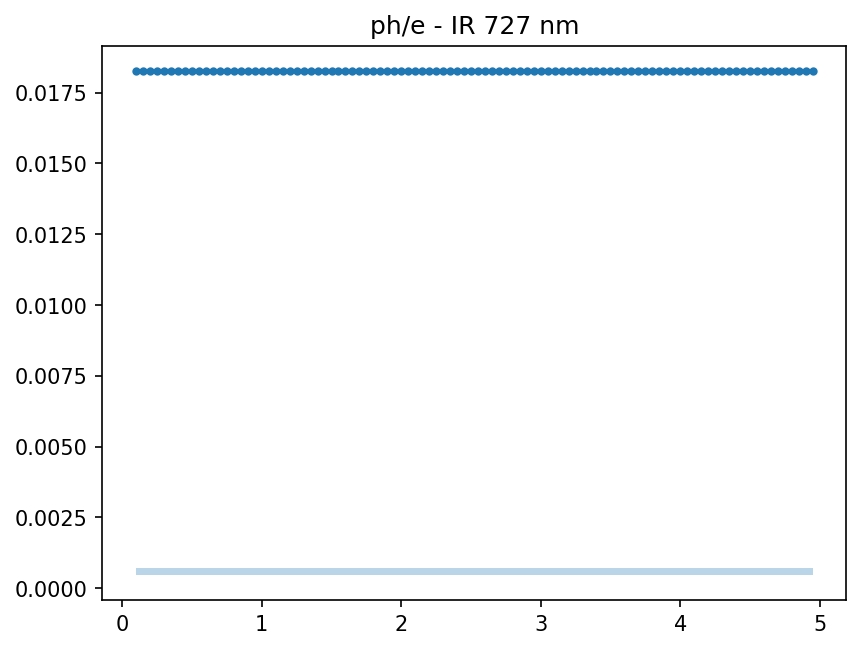

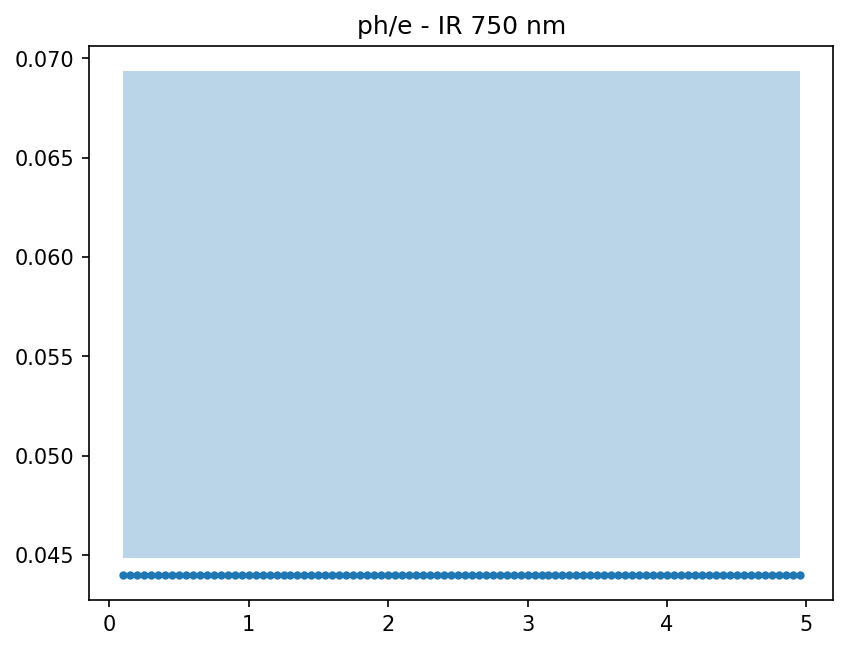

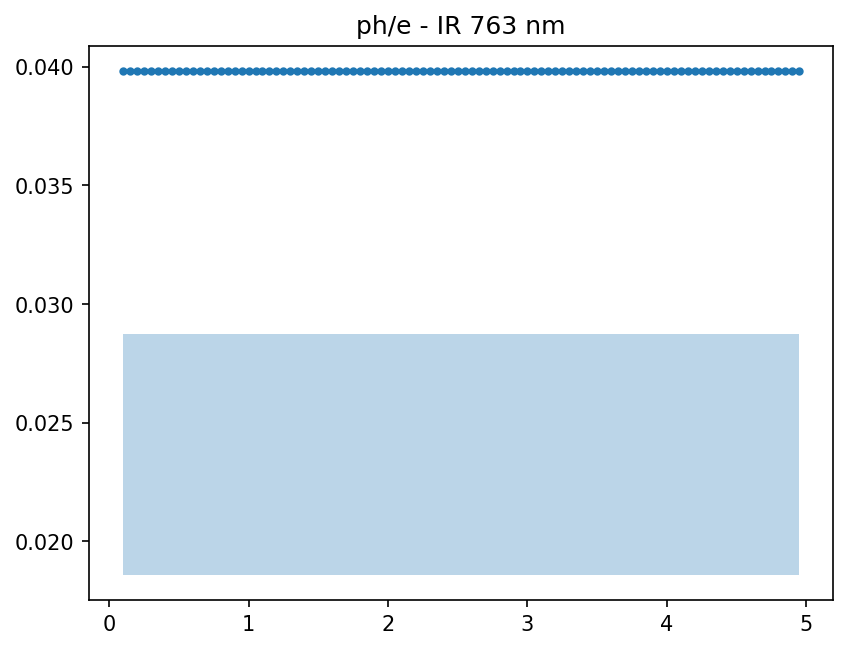

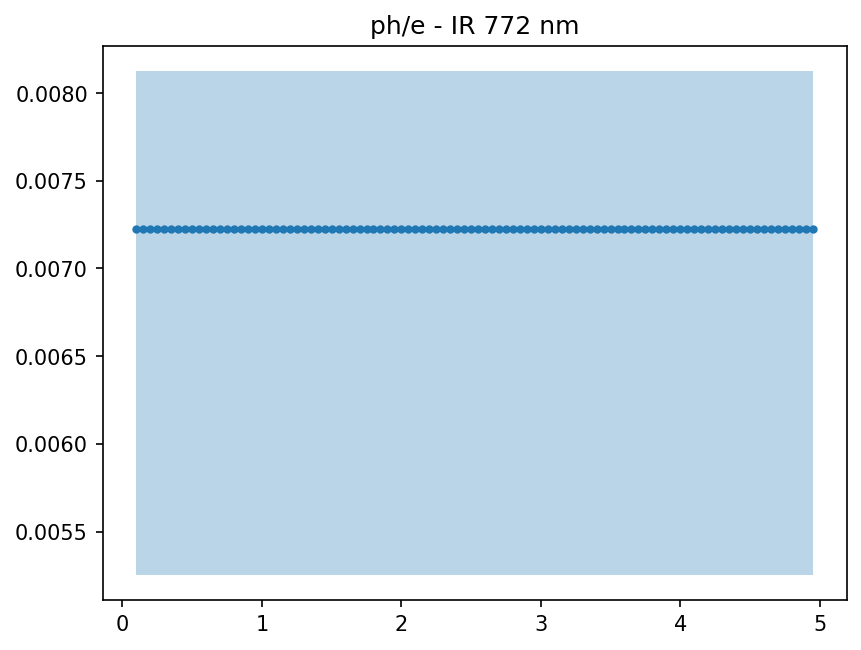

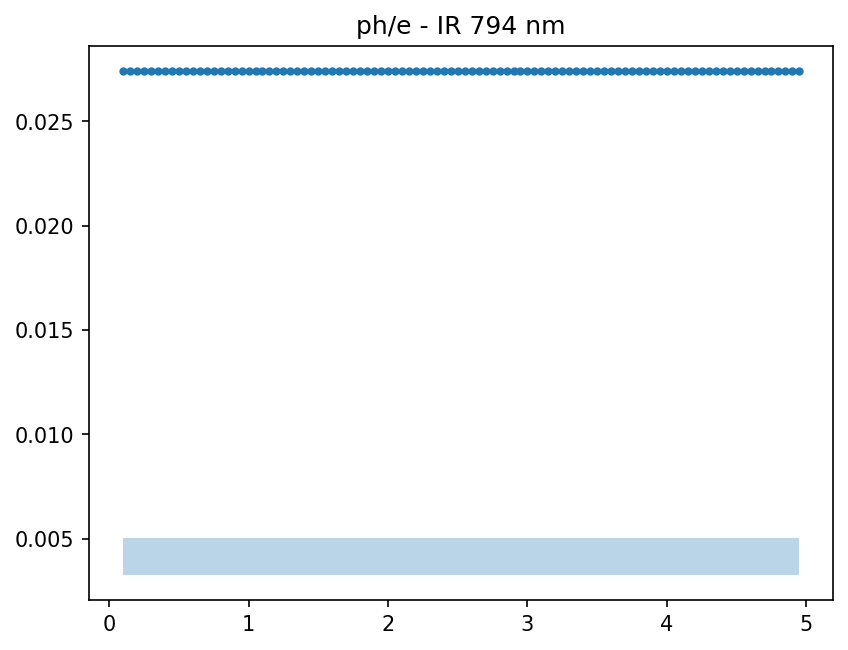

In [ ]:
array_ph_e_ir_lowP = scan_P_ar_ir(1e-1, 5, 0.5e-1, 0.05, 'ar', 80, 20, 8.4, 0.57, 10000, quench_ion=7, df_results_ir=df_results_ir, include_cf3=False, **fit_parameters_wo_uncertainties)

P_array = np.arange(1e-1, 5, 0.5e-1)

for pos in keys:
    fig, ax = plt.subplots(dpi=150)
    y1=yields_arcf4_8020_50_mbar['ir'][pos] - errors_arcf4_8020_50mbar['ir'][pos]
    y2=yields_arcf4_8020_50_mbar['ir'][pos] + errors_arcf4_8020_50mbar['ir'][pos]
    #ax.axhline()
    ax.fill_between(x=P_array,y1=y1, y2=y2, alpha=0.3)

    ph_e_sim = 

equations = {
    "vis": theory_yield_N2_uv,
}

experimental_data = {
    "vis": yield_N2_uv,[]
    for dic in array_ph_e_ir_lowP:
        ph_e_sim.append(dic[pos])

    ax.plot(P_array, ph_e_sim,'.-')
    ax.set_title(f'ph/e - IR {pos} nm')
    
    